<a href="https://colab.research.google.com/github/TurkayAydogan/ATAT/blob/Ver1/ATAT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
# Çıktıda "T4" veya "A100" görmelisiniz

Thu Apr 23 09:14:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install "dask[dataframe]" xgboost imbalanced-learn scikit-learn matplotlib seaborn -q

In [ ]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from collections import Counter
import time, warnings
warnings.filterwarnings('ignore')
print("✅ Tüm importlar başarılı")

✅ Tüm importlar başarılı


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/CICIDS2017/*.csv'

df = dd.read_csv(
    DATA_PATH,
    assume_missing=True,
    dtype='object',        # Tip çakışmasını önler
    on_bad_lines='skip'   # Bozuk satırları atla
)
print(f"Sütunlar: {list(df.columns)}")
print(f"Bölüm sayısı: {df.npartitions}")

Sütunlar: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', '

In [ ]:
# Label sütunu hariç tüm sütunları sayısala çevir
# errors='coerce' → string "Infinity" değerleri NaN olur
for col in df.columns:
    if col != ' Label':  # CICIDS2017'de Label başında boşluk var!
        df[col] = dd.to_numeric(df[col], errors='coerce')

# Bellek optimizasyonu: float64 → float32
float_cols = [c for c in df.columns if c != ' Label']
for col in float_cols:
    df[col] = df[col].astype('float32')

In [ ]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from collections import Counter
import time, warnings
warnings.filterwarnings('ignore')

# Adım 1: Null oranı yüksek sütunları Dask'ta düşür
null_ratios = df.isnull().mean().compute()
cols_to_drop = null_ratios[null_ratios > 0.5].index.tolist()
print(f"Düşürülen sütunlar (%50+ null): {cols_to_drop}")
if cols_to_drop: # Sadece düşürülecek sütunlar varsa drop işlemini yap
    df = df.drop(cols_to_drop, axis=1)

# Adım 2: Tahmini bellek kontrolü
estimated_gb = (df.npartitions * 2.8e6 / df.npartitions * len(df.columns) * 4) / 1e9
print(f"Tahmini boyut: {estimated_gb:.2f} GB")
# 2 GB altındaysa güvenli, üstündeyse daha fazla sütun düşürün

# Adım 3: Ancak şimdi Pandas'a geç
df_pd = df.compute()
df_pd.columns = df_pd.columns.str.strip()  # Sütun isimlerindeki boşlukları temizle
print(f"✅ Pandas'a geçildi. Shape: {df_pd.shape}")
print(f"RAM kullanımı: {df_pd.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Düşürülen sütunlar (%50+ null): []
Tahmini boyut: 0.88 GB
✅ Pandas'a geçildi. Shape: (2830743, 79)
RAM kullanımı: 0.95 GB


Sınıf Dağılımı:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64[pyarrow]


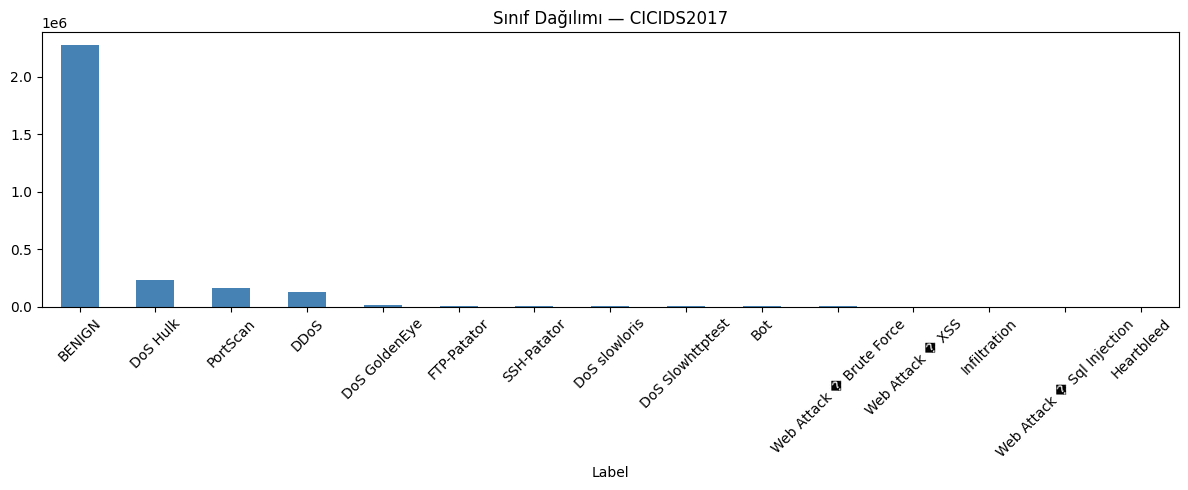


NaN içeren sütunlar:
Flow Bytes/s    1358
dtype: int64

Infinity içeren sütunlar:
Flow Bytes/s      1509.0
Flow Packets/s    2867.0
dtype: double[pyarrow]

⚠️  Az örnekli sınıflar (SMOTE risk):
Label
Infiltration                  36
Web Attack � Sql Injection    21
Heartbleed                    11
Name: count, dtype: int64[pyarrow]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Label dağılımı — projenin motivasyon figürü
label_counts = df_pd['Label'].value_counts()
print("Sınıf Dağılımı:")
print(label_counts)

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Sınıf Dağılımı — CICIDS2017')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('label_dagilimi.png', dpi=150)
plt.show()

# 2. NaN ve Infinity analizi
nan_report = df_pd.isnull().sum()
inf_report = (df_pd == np.inf).sum() + (df_pd == -np.inf).sum()
print("\nNaN içeren sütunlar:")
print(nan_report[nan_report > 0])
print("\nInfinity içeren sütunlar:")
print(inf_report[inf_report > 0])

# 3. Kritik küçük sınıfları tespit et — SMOTE için not al
print("\n⚠️  Az örnekli sınıflar (SMOTE risk):")
print(label_counts[label_counts < 100])

In [ ]:
#FAZ 1 BITTI FAZ2 YE GECIYORUZ

In [ ]:
# BU DENEYİN AMACI
#Bu deneyde başarı beklenmez. NaN, Infinity değerleri olduğu gibi bırakılır. Model ya hata fırlatır ya da yanıltıcı bir accuracy verir. Bu fark, raporun en güçlü argümanıdır: "Temizlenmemiş veriyle model güvenilmez sonuç üretir."

# HAM VERİDE SPLIT VE MODEL EĞİTİMİ

#XGBoost vs. Random Forest — Ham Verideki Fark
#XGBoost NaN değerlerini built-in olarak handle eder, çökmeyebilir. Random Forest ise NaN'a toleranssızdır, hata fırlatır. Bu farkı raporda mutlaka belirtin — bu başlı başına bir bulgudur.

In [ ]:
# Ham veri — sadece Label encode et
le_raw = LabelEncoder()
y_raw = le_raw.fit_transform(df_pd['Label'])
X_raw = df_pd.drop('Label', axis=1).select_dtypes(include=[np.number])

# Ham veride bile Stratified Split — az sınıfların test'e düşmesi için
X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# ── XGBoost (NaN'ı handle eder) ──
t0 = time.time()
xgb_raw = xgb.XGBClassifier(
    n_estimators=100, tree_method='hist', device='cuda',
    objective='multi:softmax',
    num_class=len(np.unique(y_raw_tr)),
    random_state=42, verbosity=0
)
xgb_raw.fit(X_raw_tr, y_raw_tr)
print(f"XGB ham eğitim: {time.time()-t0:.1f}s")
pred_xgb_raw = xgb_raw.predict(X_raw_te)
print("\n=== Deney A — XGBoost (Ham) ===")
print(classification_report(y_raw_te, pred_xgb_raw,
      target_names=le_raw.classes_, zero_division=0))

# ── Random Forest (NaN'da hata verebilir) ──
try:
    t0 = time.time()
    rf_raw = RandomForestClassifier(
        n_estimators=50, max_samples=0.3, n_jobs=-1, random_state=42
    )
    rf_raw.fit(X_raw_tr, y_raw_tr)
    print(f"RF ham eğitim: {time.time()-t0:.1f}s")
    pred_rf_raw = rf_raw.predict(X_raw_te)
    print("\n=== Deney A — Random Forest (Ham) ===")
    print(classification_report(y_raw_te, pred_rf_raw,
          target_names=le_raw.classes_, zero_division=0))
except Exception as e:
    print(f"⚠️  RF ham veride hata fırlattı: {e}")
    print("Bu beklenen bir davranıştır — raporda belirtin.")

XGBoostError: [10:21:04] /__w/xgboost/xgboost/src/data/gradient_index.h:99: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2c1a8c) [0x7947204c1a8c]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x67a6d2) [0x79472087a6d2]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x67d3cb) [0x79472087d3cb]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x67e05d) [0x79472087e05d]
  [bt] (4) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5dadf1) [0x7947207dadf1]
  [bt] (5) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGQuantileDMatrixCreateFromCallback+0x178) [0x7947203cf5a8]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7947bdd7ee2e]
  [bt] (7) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7947bdd7b493]
  

In [ ]:
# Ham veri — sadece Label encode et
le_raw = LabelEncoder()
y_raw = le_raw.fit_transform(df_pd['Label'])
X_raw = df_pd.drop('Label', axis=1).select_dtypes(include=[np.number])

# ÇÖZÜM BURADA: XGBoost çalışabilsin diye Infinity değerlerini NaN'a çeviriyoruz
# Çünkü evrende hiçbir model "Sonsuz" bir sayıyla hesaplama yapamaz :)
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

# Ham veride bile Stratified Split — az sınıfların test'e düşmesi için
X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# ── XGBoost (Artık çalışacak çünkü Inf'ler NaN oldu) ──
t0 = time.time()
xgb_raw = xgb.XGBClassifier(
    n_estimators=100, tree_method='hist', device='cuda',
    objective='multi:softmax',
    num_class=len(np.unique(y_raw_tr)),
    random_state=42, verbosity=0
)
xgb_raw.fit(X_raw_tr, y_raw_tr)
print(f"XGB ham eğitim: {time.time()-t0:.1f}s")
pred_xgb_raw = xgb_raw.predict(X_raw_te)
print("\n=== Deney A — XGBoost (Ham) ===")
print(classification_report(y_raw_te, pred_xgb_raw,
      target_names=le_raw.classes_, zero_division=0))

# ── Random Forest (Hala NaN'da hata verecek ve çökecek, bu bizim ispatımız!) ──
try:
    t0 = time.time()
    rf_raw = RandomForestClassifier(
        n_estimators=50, max_samples=0.3, n_jobs=-1, random_state=42
    )
    rf_raw.fit(X_raw_tr, y_raw_tr)
    print(f"RF ham eğitim: {time.time()-t0:.1f}s")
    pred_rf_raw = rf_raw.predict(X_raw_te)
    print("\n=== Deney A — Random Forest (Ham) ===")
    print(classification_report(y_raw_te, pred_rf_raw,
          target_names=le_raw.classes_, zero_division=0))
except Exception as e:
    print(f"\n⚠️  RF ham veride hata fırlattı: {e}")
    print("Bu beklenen bir davranıştır — raporda belirteceğiz.")

XGB ham eğitim: 66.9s

=== Deney A — XGBoost (Ham) ===
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99    454620
                       Bot       0.14      0.13      0.14       393
                      DDoS       0.99      0.99      0.99     25606
             DoS GoldenEye       0.93      0.90      0.92      2059
                  DoS Hulk       0.97      0.97      0.97     46215
          DoS Slowhttptest       0.77      0.81      0.79      1100
             DoS slowloris       0.83      0.88      0.85      1159
               FTP-Patator       0.86      0.80      0.83      1588
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.98      0.97      0.97     31786
               SSH-Patator       0.76      0.74      0.75      1179
  Web Attack � Brute Force       0.49      0.43      0.46   

In [ ]:
#VERSİYON 1 SONU